**This dataset includes 23486 rows and 10 feature variables. Each row corresponds to a customer review, and includes the variables:**  

**Clothing ID:** Integer Categorical variable that refers to the specific piece being reviewed.  
**Age:** Positive Integer variable of the reviewers age.  
**Title:** String variable for the title of the review.  
**Review Text:** String variable for the review body.  
**Rating:** Positive Ordinal Integer variable for the product score granted by the customer from 1 Worst, to 5 Best.  
**Recommended IND:** Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.  
**Positive Feedback Count:** Positive Integer documenting the number of other customers who found this review positive.  
**Division Name:** Categorical name of the product high level division.  
**Department Name:** Categorical name of the product department name.  
**Class Name:** Categorical name of the product class name.  

Importing Libraries and Loading Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

df = pd.read_csv('..\data\Womens Clothing E-Commerce Reviews.csv', index_col=0)

In [8]:
df.shape

(23486, 10)

In [9]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Checking for Missing Values

In [10]:
print("Data Types and Missing Values")
df.info()

print("Missing Values Count")
print(df.isnull().sum())

Data Types and Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB
Missing Values Count
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND      

In [ ]:
# df.drop(columns=['Clothing ID'], axis=1, inplace=True) 
df = df.dropna(subset=['Review Text'])
df = df.dropna(subset=['Division Name', 'Department Name', 'Class Name'])
df['Title'] = df['Title'].fillna('')
print(df.isnull().sum())

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


In [17]:
df['Word_Count'] = df['Review Text'].apply(lambda x: len(str(x).split()))

df['Char_Count'] = df['Review Text'].apply(len)

# Başlık ve Yorumu birleştirip tam bir metin alanı oluşturalım (NLP modelleri için hazırlık)
df['Full_Text'] = df['Title'] + " " + df['Review Text']

print(df.shape)
display(df.head(5))

(22628, 13)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Word_Count,Char_Count,Full_Text
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8,53,Absolutely wonderful - silky and sexy and com...
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62,303,Love this dress! it's sooo pretty. i happen...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98,500,Some major design flaws I had such high hopes ...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,22,124,"My favorite buy! I love, love, love this jumps..."
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,36,192,Flattering shirt This shirt is very flattering...


Visualization

In [68]:
sns.set_style("whitegrid")

<Axes: xlabel='Age', ylabel='Count'>

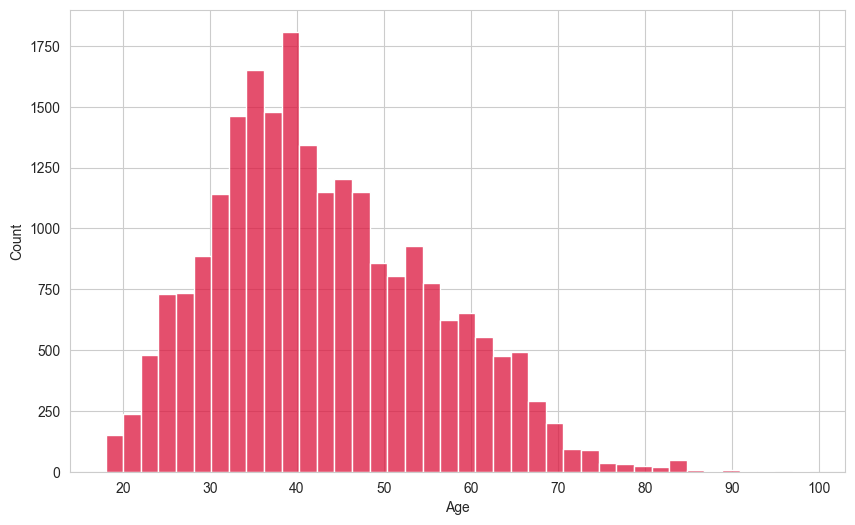

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Age', bins=40, color='crimson')

C:\Users\nuhme\AppData\Local\Temp\ipykernel_6564\433020311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='Spectral')


Text(0.5, 1.0, 'Rating Distribution')

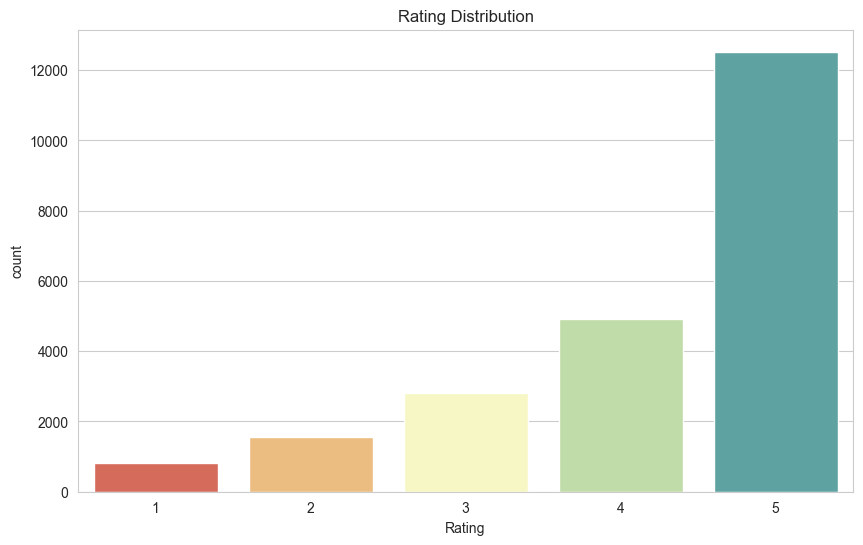

In [70]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=df, palette='Spectral')
plt.title('Rating Distribution')

C:\Users\nuhme\AppData\Local\Temp\ipykernel_6564\3446394013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Word_Count', data=df, palette='Spectral')


<Axes: xlabel='Rating', ylabel='Word_Count'>

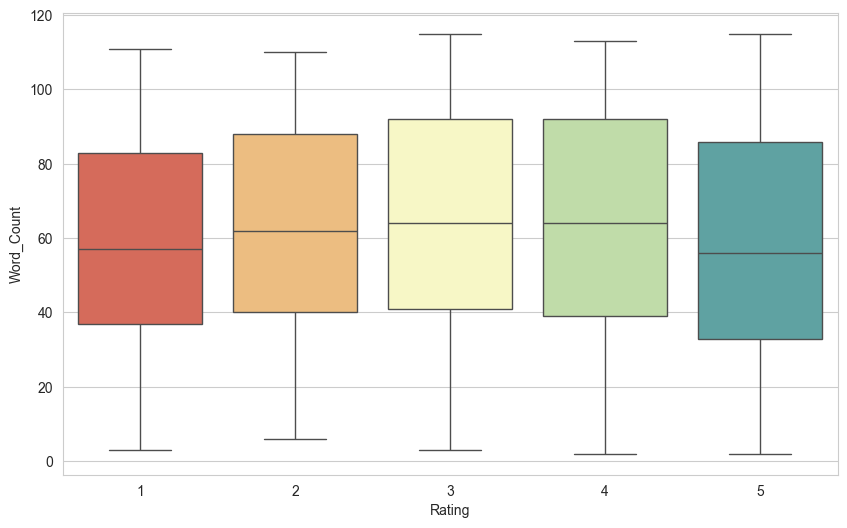

In [71]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Word_Count', data=df, palette='Spectral')

<Axes: xlabel='Count', ylabel='Class Name'>

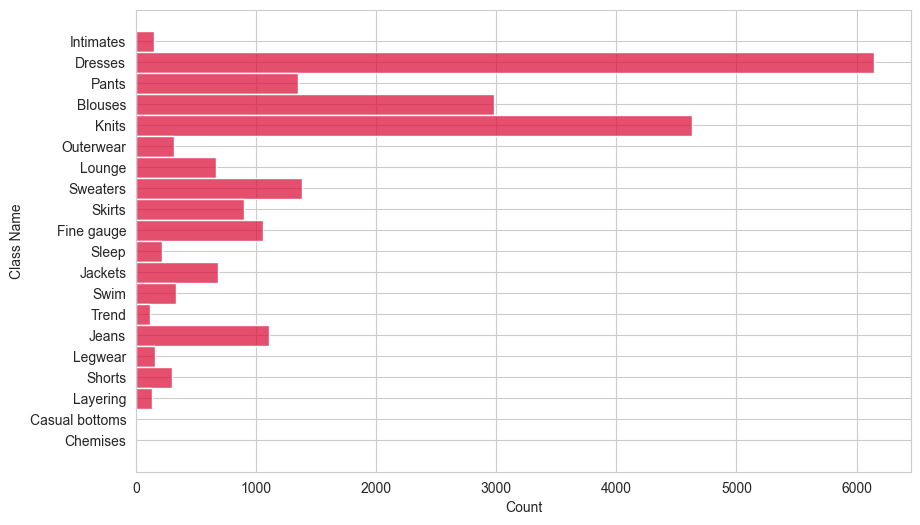

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df, y='Class Name', color='crimson')

Text Preprocessing & Cleaning